# Kiyohara public-transport isochrone analysis

This notebook creates 30-minute and 60-minute public-transport accessibility polygons to the Kiyohara industrial-area LRT stop. It implements the requested travel-time workflow:

`area -> walk X min -> bus stop / rail node -> feeder bus Y min -> LRT stop -> LRT Z min -> destination`

Assumptions used by the workflow:

- `Z`: LRT travel time from each LRT stop to the destination, estimated from cumulative stop-to-stop route length in `lrt_stops.shp` at 20 km/h.
- `Y`: feeder-bus travel time from each bus stop to the best LRT transfer stop, estimated along `N07-11_09_GML.shp` bus route lines at 20 km/h when available.
- `X`: remaining walking time, calculated as threshold minus `Y + Z` and expanded along the road network when an N13 road layer is available.

The road-network step avoids simple circular buffers when road lines are present. If required local data are missing, the notebook reports the missing inputs rather than silently fabricating results.


## Expected local/attached data

Place complete shapefile sets under `data/`, including `.shp`, `.shx`, `.dbf`, and `.prj` when available. The bus route map attached to the request should be available as:

- `data/N07-11_09_GML.shp` (plus sidecars)

The workflow also searches common alternatives recursively under `data/` for:

- `lrt_stops.shp` (required)
- `P11-22_09.shp` bus stop points (recommended)
- `N13-24_5439.shp` road lines (recommended for road-network walking isochrones)


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if str(REPO_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))

import kiyohara_transit_isochrone as iso


In [2]:
# Configure the destination stop.
# Use a more specific expression if the target should be a particular LRT stop,
# for example: r"清原地区市民センター前" or r"芳賀・高根沢工業団地".
DATA_DIR = "data"
OUTPUT_DIR = "outputs/kiyohara_isochrone"
TARGET_STOP_REGEX = r"清原|工業団地"
THRESHOLDS = [30, 60]


In [3]:
# Input discovery and sidecar check.
# This should print the resolved local layers before running the analysis.
iso.check_inputs(Path(DATA_DIR))


lrt_stops   : data/lrt_stops.shp
bus_stops   : data/P11-22_09.shp
bus_routes  : data/N07-11_09.shp
roads       : data/N13-24_5439.shp
adm2        : data/gadm41_JPN_2.shp


True

In [4]:
# Run the full 30/60-minute isochrone analysis.
args = iso.parse_args([
    "--data-dir", DATA_DIR,
    "--output-dir", OUTPUT_DIR,
    "--target-stop-regex", TARGET_STOP_REGEX,
    "--thresholds", *map(str, THRESHOLDS),
])
iso.run_analysis(args)


lrt_stops   : data/lrt_stops.shp
bus_stops   : data/P11-22_09.shp
bus_routes  : data/N07-11_09.shp
roads       : data/N13-24_5439.shp
adm2        : data/gadm41_JPN_2.shp

Destination LRT stop: 芳賀・高根沢工業団地


/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(
/home/miwatanabe/private/UtsunomiyaLRT/scripts/kiyohara_transit_isochrone.py:716: UserWarning: N07-11_09.shp has no CRS; assuming EPSG:6668.
  bus_routes = explode_lines(read_layer(layers["bus_routes"])) if layers["bus_routes"] else None
/home/miwatanabe/private/UtsunomiyaLRT/scripts/kiyohara_transit_isochrone.py:661: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  layer.to_file(shp_dir / f"kiyohara_isochrone_{threshold}min.shp", encoding="utf-8")
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'threshold_min' to 'threshold_'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'access_nodes' to 'access_n


Wrote outputs to outputs/kiyohara_isochrone
30 min isochrone area: 21.75 km2 (road_network)
60 min isochrone area: 152.68 km2 (road_network)


0

## Outputs

Expected outputs are written under `outputs/kiyohara_isochrone/`:

- `kiyohara_transit_isochrones.gpkg` with `isochrone_30min`, `isochrone_60min`, `access_nodes`, and `lrt_travel_times` layers
- `shapefiles/kiyohara_isochrone_30min.shp` and `shapefiles/kiyohara_isochrone_60min.shp`
- `tables/kiyohara_transit_access_nodes.csv` and `tables/kiyohara_lrt_travel_times.csv`
- `figures/kiyohara_transit_isochrones.png`


/tmp/ipykernel_1103/4005929484.py:71: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


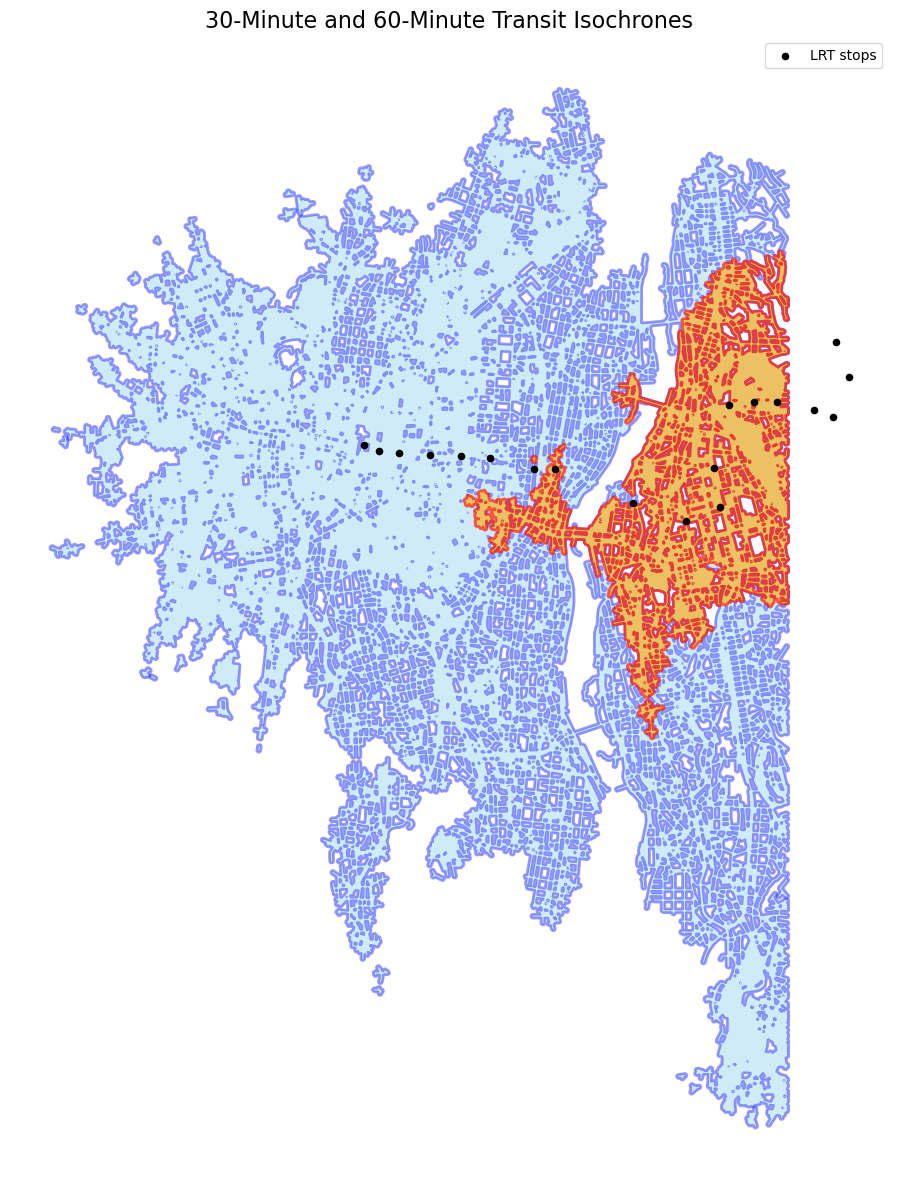

In [6]:
# Plot both 30-minute and 60-minute isochrones together with labels

from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Load generated layers
gpkg_path = Path(OUTPUT_DIR) / "kiyohara_transit_isochrones.gpkg"

iso30 = gpd.read_file(gpkg_path, layer="isochrone_30min")
iso60 = gpd.read_file(gpkg_path, layer="isochrone_60min")
lrt_times = gpd.read_file(gpkg_path, layer="lrt_travel_times")

# Reproject to Web Mercator for plotting consistency
iso30 = iso30.to_crs(epsg=3857)
iso60 = iso60.to_crs(epsg=3857)
lrt_times = lrt_times.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(12, 12))

# Plot 60-minute isochrone first
iso60.plot(
    ax=ax,
    color="skyblue",
    edgecolor="blue",
    alpha=0.4,
    linewidth=2,
    label="60-minute isochrone"
)

# Plot 30-minute isochrone on top
iso30.plot(
    ax=ax,
    color="orange",
    edgecolor="red",
    alpha=0.6,
    linewidth=2,
    label="30-minute isochrone"
)

# Plot LRT stops
lrt_times.plot(
    ax=ax,
    color="black",
    markersize=20,
    label="LRT stops"
)

# Add labels to LRT stops if a name column exists
# possible_name_cols = ["name", "Name", "stop_name", "STOP_NAME"]

label_col = None
# for col in possible_name_cols:
#     if col in lrt_times.columns:
#         label_col = col
#         break

if label_col:
    for idx, row in lrt_times.iterrows():
        ax.annotate(
            text=str(row[label_col]),
            xy=(row.geometry.x, row.geometry.y),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=8
        )

# Map formatting
ax.set_title("30-Minute and 60-Minute Transit Isochrones", fontsize=16)
ax.legend()
ax.set_axis_off()

plt.tight_layout()
plt.show()